# Sample Spaces and Events

*Following Blitzstein, J. K., & Hwang, J. (2019). Introduction to Probability (2nd ed.), Chapter 1.*

## Index
1. [The Dartboard Analogy](#1)
2. [Diagram](#2)
3. [Example: Dice and Coin Flips](#3)
4. [Plain English](#4)
5. [Technical Definitions](#5)
6. [Worked Problem: The Trader](#6)
7. [References](#7)

In [1]:
import numpy as np
from itertools import product

<a id="1"></a>
## 1. The Dartboard Analogy

Imagine throwing a dart at a dartboard.

The **sample space** is the entire dartboard: every possible place where the dart could land.

An **event** is a particular region of the dartboard, such as the red area.

If the dart lands inside the red area, the event occurred.

So, the sample space is all the possibilities, while an event is a collection of possibilities that satisfy a particular condition.

<a id="2"></a>
## 2. Diagram

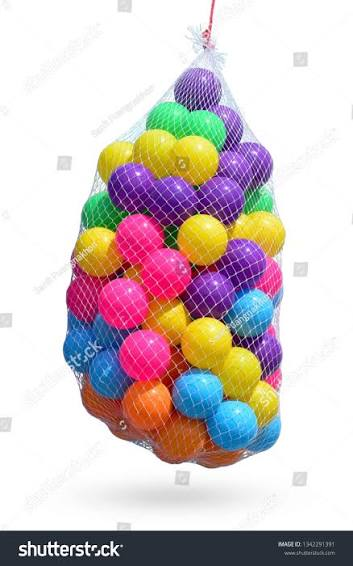

<a id="3"></a>
## 3. Example: Dice and Coin Flips

#### Simple Example

 If we roll a six-sided die, there are six
possible results that are mutually exclusive (the die cannot land on two numbers
at the same time). These six outcomes form the sample space Ω := {1,2,3,4,5,6}
associated with the die roll. In this case, the sample space is a finite set. (ps4ds)

####  Terminology for Events and Sets

A coin is flipped 10 times. Writing Heads as $H$ and Tails as $T$, a possible outcome (pebble) is $HHHTHHTTHT$, and the sample space is the set of all possible strings of length 10 of $H$’s and $T$’s. We can (and will) encode $H$ as 1 and $T$ as 0, so that an outcome is a sequence $(s_1, \dots, s_{10})$ with $s_j \in \{0, 1\}$, and the sample space is the set of all such sequences. Now let’s look at some events:

Let $A_1$ be the event that the first flip is Heads. As a set,$$A_1 = \{(1, s_2, \dots, s_{10}) : s_j \in \{0, 1\} \text{ for } 2 \le j \le 10\}$$This is a subset of the sample space, so it is indeed an event; saying that $A_1$ occurs is the same thing as saying that the first flip is Heads. Similarly, let $A_j$ be the event that the $j\text{th}$ flip is Heads for $j = 2, 3, \dots, 10$.


Let $B$ be the event that at least one flip was Heads. As a set,$$B = \bigcup_{j=1}^{10} A_j $$ or $$B=A1​∪A2​∪⋯∪A10$$

 Let $C$ be the event that all the flips were Heads. As a set,$$C = \bigcap_{j=1}^{10} A_j$$ 
 
 In set notation, **AND** is represented by $\cap$ (intersection):

$$
C = A_1 \cap A_2 \cap \cdots \cap A_{10}
$$

 Let $D$ be the event that there were at least two consecutive Heads. As a set,$$D = \bigcup_{j=1}^{9} (A_j \cap A_{j+1})$$

 

(Blitzstein)

The die needs nothing more than the set `{1, 2, 3, 4, 5, 6}`. The coin strings are more interesting to build, so Python takes over from here, using the `H -> 1`, `T -> 0` encoding described above:

In [2]:
omega = {seq for seq in product((1, 0), repeat=10)}
print("|Omega| =", len(omega))

def as_ht(seq):
    return "".join("H" if bit else "T" for bit in seq)

example = next(iter(omega))
print("one outcome:", as_ht(example))

|Omega| = 1024
one outcome: HHHTTTTHHH


In [3]:
Aj = [{s for s in omega if s[j] == 1} for j in range(10)]   # A_j: j-th flip Heads

B = {s for s in omega if 1 in s}                             # at least one Heads
C = {s for s in omega if all(bit == 1 for bit in s)}         # all Heads
D = {s for s in omega if any(s[j] == s[j+1] == 1 for j in range(9))}

print("|A_1| =", len(Aj[0]), " |B| =", len(B), " |C| =", len(C), " |D| =", len(D))

print()
print("identity checks against the formulas above:")
print("B  == union A_j           :", B == set().union(*Aj))
print("C  == intersection A_j    :", C == set.intersection(*Aj))
D_union = set().union(*({s for s in omega if s[j] == s[j+1] == 1} for j in range(9)))
print("D  == union (A_j & A_j+1) :", D == D_union)

|A_1| = 512  |B| = 1023  |C| = 1  |D| = 880

identity checks against the formulas above:
B  == union A_j           : True
C  == intersection A_j    : True
D  == union (A_j & A_j+1) : True


<a id="4"></a>
## 4. Plain English

The **sample space** is all possible outcomes of an **experiment**. An **event** is a collection of possible outcomes that share a particular characteristic.

The sample space S of an experiment
is the set of all possible outcomes of the experiment. An event A is a subset of the
sample space S, and we say that A occurred if the actual outcome is in A. (Blitzstein)

In order to define probabilities associated with an uncertain phenomenon, we
interpret the phenomenon as an experiment with multiple possible outcomes.
The set of all possible outcomes is called the sample space, usually denoted by Ω.
As the following examples show, the sample space can be discrete or continuous. (ps4ds)

<a id="5"></a>
## 5. Technical Definitions



The set of all possible outcomes.$$s \in S$$Event ($A$): A subset of the sample space, representing a collection of possible outcomes.$$A \subseteq S$$Actual Outcome ($s_{\text{actual}}$): The specific outcome that occurs after the experiment is conducted.$$s_{\text{actual}} \in S$$An event $A$ occurs if and only if the actual outcome belongs to $A$:$$s_{\text{actual}} \in A \implies \text{Event } A \text{ occurred}$$More formally, using an indicator function $I_A$:$$I_A(s_{\text{actual}}) = \begin{cases} 1 & \text{if } s_{\text{actual}} \in A \quad (\text{Event } A \text{ occurred}) \\ 0 & \text{if } s_{\text{actual}} \notin A \quad (\text{Event } A \text{ did not occur}) \end{cases}$$

Implementing $I_A$ takes one line. Draw an outcome at random and ask whether each event occurred:

In [4]:
rng = np.random.default_rng(12)

s_actual = tuple(rng.integers(0, 2, size=10))

def I_A(s, A):
    return int(s in A)

print("actual outcome:", as_ht(s_actual))
for name, event in [("A_5", Aj[4]), ("B", B), ("C", C)]:
    print(f"I_{name}(s_actual) = {I_A(s_actual, event)}")

actual outcome: HTHHTTTTHT
I_A_5(s_actual) = 0
I_B(s_actual) = 1
I_C(s_actual) = 0


<a id="6"></a>
## 6. Worked Problem: The Trader

Suppose a trader makes one trade every 10 minutes. For each trade, the trader either makes a profit (P) or a loss (L).

We want to describe the sample space for the trader's results over 4 days.

Assuming the trader operates continuously for 24 hours per day:

In [5]:
trades_per_day = (24 * 60)/10
n_days = 4
n_trades = 4 * trades_per_day

n_trades

576.0

Therefore, a single outcome over the 4 days is a sequence of 576 trading results:

$$
(s_1,s_2,\ldots,s_{576}),
\qquad s_i\in\{P,L\}.
$$

For example, a particular outcome might look like

$$
(P,P,L,P,L,\ldots,P).
$$

Here, $s_i$ represents the result of the $i$-th trade:

$$
s_i =
\begin{cases}
P, & \text{if the $i$-th trade is profitable},\\
L, & \text{if the $i$-th trade is a loss}.
\end{cases}
$$

The **sample space** $\Omega$ is the set of all possible sequences of 576 trading results:

$$
\boxed{
\Omega
=
\left\{
(s_1,s_2,\ldots,s_{576})
:
s_i\in\{P,L\}
\right\}.
}
$$

Equivalently, we can write this more compactly as

$$
\boxed{
\Omega=\{P,L\}^{576}.
}
$$

Since each of the 576 trades has two possible outcomes, the sample space contains

$$
|\Omega|=2^{576}
$$

possible outcomes.

The formula $|\Omega| = 2^{576}$ looks abstract until Python evaluates it exactly, since integers of any size are native. Then pull one concrete outcome out of the space:

In [6]:
n_outcomes = 2 ** int(n_trades)
print(f"|Omega| = {n_outcomes:,}")

trader_outcome = "".join("P" if p else "L" for p in rng.integers(0, 2, size=int(n_trades)))
print("one possible outcome:", trader_outcome[:60] + ", ...")

|Omega| = 247,330,401,473,104,534,060,502,521,019,647,190,035,131,349,101,211,839,914,063,056,092,897,225,106,531,867,170,316,401,061,243,044,989,597,671,426,016,139,339,351,365,034,306,751,209,967,546,155,101,893,167,916,606,772,148,699,136
one possible outcome: LLPPPLLPLPPLLPLLPLLLLLPLPPLLPLPPPPLPPPLLPPLPLPPLPLPPPPLPPLPL, ...


<a id="7"></a>
## 7. References

- Blitzstein, J. K., & Hwang, J. (2019). *Introduction to Probability* (2nd ed.). CRC Press.
- Taboga, M., *Probability for Data Scientists* (ps4ds).